# Atmospheric Thermodynamics
In this notebook are defined a set of physical and thermodynamic constants, state variables and processes. The notebook is based mostly on ch.3 and ch.4 of the book by R. Stull *Practical Meteorology*

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

In [2]:
%run -i climate_lib.py

## Dry adiabatic lapse rate
The 1st principle of thermdynamics, that is the principle of conservation of energy, for one mole of a perfect gas can be written as
$$c_p dT - \frac{1}{\rho}dp = dq$$
where $\rho$ is the density. For an adiabatic process under the hydrostatic approximation, where $dp = -\rho g dz$ the equaton becomes
$$c_p dT + gdz = 0$$
from which we can derive the vertical temperature gradient
$$\frac{dT}{dz} = -\frac{g}{c_p}$$
We define the dry adiabatic lapse rate as 
$$\Gamma_d \equiv -\frac{dT}{dz} = \frac{g}{c_p}$$
Assuming the gravity acceleration and the specific heat constant we can integrate the equation
$$\Gamma_d \int_{z_0}^z dz = -\int_{T_0}^T dT$$
that is
$$T = T_0 - \Gamma_d (z - z_0)$$

In [10]:
from metpy import constants as c
dry_lapse_rate = c.earth_gravity / c.Cp_d
print('Dry adiabat lapse rate: {:.4f}'.format(dry_lapse_rate))

Dry adiabat lapse rate: 0.0098 kelvin * kilogram * meter / joule / second ** 2


We can express the temperature gradient as a function of the pressure, from the hidrostatic approximation
$$dz = -\frac{1}{\rho g}dp$$
and the equation of state of perfect gasses
$$p = \rho R_d T$$
we have
$$\frac{dT}{dp}=\frac{R_d T}{c_p p}$$
or
$$dlnT = \frac{R_d}{c_p}dlnp$$
that can be easily solved by integrating separately the two members of the equation
$$\int_{T_0}^T dlnT = \frac{R_d}{c_p} \int_{p_0}^p dlnp$$
from which we have
$$ln(\frac{T}{T_0}) = \frac{R_d}{c_p} ln(\frac{p}{p_0}) = ln((\frac{p}{p_0})^{\frac{R_d}{c_p}})$$
and finally by taking the exponential of both members
$$T = T_0(\frac{p}{p_0})^{\frac{R_d}{c_p}}$$

## Potential temperature
In an adiabatic process the parcel of air doesn't exchange heat with the ambient air so that its temperature changes only because of the expansion or compression while rising or sinking. For this reason a new variable, the potential temperature $\theta$, is defined to express the sensible heat of the parcel undergoing an adiabatic process. If we know the air temperature $T_0$ at height $z_0$ we can calculate the potential temperature of the dry air parcel at z
$$\theta(z) = T_0 -\Gamma_d (z - z_0)$$
If, instead, we know the temperature $T_0$ at pressure $p_0$ the potential temperature is
$$\theta(p)=T_0 (\frac{p}{p_0})^{\frac{R_d}{c_p}}$$

A thermo diagram contains, in addition to the pressure and temperature grid lines, also dry and wet adiabats that can help at intepreting the state of the atmosphere from the temperature profile. The dry adiabats can be drawn from the equation of the potential temperature as a function of pressure used as a proxy for the elevation
$$T_2 = T_1 \cdot \left ( \frac{p_2}{p_1}\right ) ^{\frac{R_d}{c_p}} $$

## Dry adiabats
We define a function to calculate the dry adiabats starting from a number of temperature $T_0$. 

In [3]:
def p_dry_adiabats():
    '''
    This function computes a set of dry adiabats
    '''
    temperatures = []
    p_0 = 100 # kPa 
    p = np.linspace(10, 100) # pressure in kPa
    t_0 = np.array([-60, -50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50, 60]) + 273.15
    for i in range(len(t_0)):
        T = t_0[i] * (p / p_0) ** (c.Rd / c.Cp_d)
        temperatures.append(T - 273.15)
    return temperatures

In [15]:
dry_adiabats = p_dry_adiabats()
len(dry_adiabats)

13

We plot the dry adiabats in a semilogarithmic 

In [16]:
p = np.linspace(10, 100)

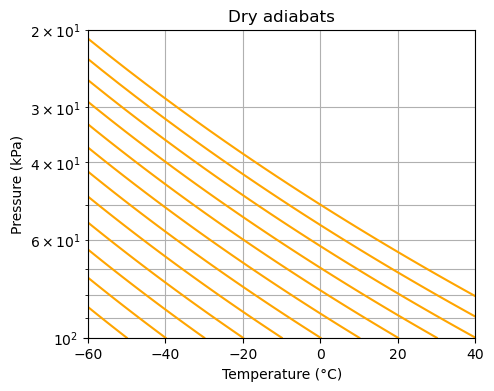

In [9]:
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot()
ax.grid(visible=True, which='major')
ax.grid(axis='both', visible=True, which='minor')
ax.set_xlim(-60, 40)
ax.set_ylim(100, 20)
ax.yaxis.set_inverted(True)
ax.set_title("Dry adiabats")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Pressure (kPa)")
for i in range(len(dry_adiabats)):
    ax.semilogy(dry_adiabats[i], p, color='orange')

## Isohumes
A isohume gives the saturated mixing ratio of water $r_s(p, T)$ at any given temperature and pressure. Isohumes are plotted as base lines on thermodiagrams. In order to plot the isohumes in a diagram we have to solve the saturated mixing ratio for the temperature using the Clausius-Clapeyron equation that gives the water vapor pressure as a function of the temperature. After some manipulation we get to the expression
$$T=\left[ \frac{1}{T_0} - \frac{R_v}{L_v} ln\frac{r_s p}{\epsilon e_0} \right]^{-1}$$

In [3]:
from metpy import constants as c
def p_isohumes():
    '''
    This function computes a set of isohumes to be used
    as baselines for a thermodiagram.
    '''
    temperatures = []
    p = np.linspace(10, 100)
    e_0 = 0.6113 # water vapor pressure at T_0
    r_s_values = np.array([0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 50]) / 1000  # in gg^(-1)
    for r_s in r_s_values: 
        d = 1 / c.T0 - (c.Rv / c.Lv) * np.log(r_s * p / (e_0 * c.epsilon))
        T = 1 / d - c.T0
        temperatures.append(T)
    return temperatures

In [74]:
p = np.linspace(10, 100)

In [75]:
t_isohumes = p_isohumes()
len(t_isohumes)

9

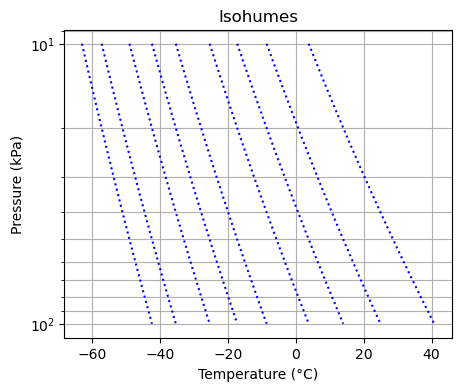

In [105]:
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot()
ax.grid(visible=True, which='major')
ax.grid(axis='both', visible=True, which='minor')
ax.yaxis.set_inverted(True)
ax.set_title("Isohumes")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Pressure (kPa)")
for i in range(len(t_isohumes)):
    ax.semilogy(t_isohumes[i], p, color='blue', linestyle=':')

## Moist adiabatic lapse rate
Here we consider a parcel of moist air, that is dry air with water vapor, rising adiabatically. The rising parcel of moist air expands and cools down with the water vapor that condenses as cloud drops reducing its cooling process. Conversely the descending parcel is compressed and heated with the cloud drops evaporating and in so doing reducing the heating process compared to a dry air parcel. The process is adiabatic but, unlike the dry adiabat, we have to consider the water content in the equation of conservation of energy
$$dq = c_p dT -RT \frac{dp}{p}$$
where
$$dq = -L_vdr$$
where $dr$ is the change in water vapor mixing ratio. The conservation of energy for the moist adiabatic process can be written as
$$c_pdT + L_vdr -RT \frac{dp}{p} = 0$$

In [50]:
from earthkit.meteo import constants as c
def moist_adiabat_lapse_rate(p, T):
    '''
    This function calculates the moist adiabatic lapse rate
    from pressure and temperature.
    '''
    e = eq_clapeyron(T)
    r_s = c.epsilon * e / (p - e)
    n = (c.Rd / c.c_pd) * T + (c.Lv / c.c_pd) * r_s
    d = (1 + c.Lv ** 2 * r_s * c.epsilon / (c.c_pd * c.Rd * T ** 2)) * p
    G_s = n / d
    return G_s

We test the function with a sample application (Stull p.102)

In [51]:
T = 10 + c.T0 # K
p = 70  # kPa
e = eq_clapeyron(T)
e

1.2323325528107945

In [52]:
r_s = c.epsilon * e / (p - e)
r_s

0.011146043802030105

In [53]:
G_s = moist_adiabat_lapse_rate(p, T)
G_s

0.5398596177919532

## Moist adiabats
We iterate over the pressure values at step of 0.2 kPa to calculate the values of the moist adiabatic lapse rate and the temperature at each step
$$T_2 = T_1 + \frac{\Delta T}{\Delta p} (p_2 - p_1)$$

In [54]:
p = np.flip(np.linspace(10, 100, 450))
T = 30 + c.T0
p_0 = p[0]
p_1 = p[1]

In [55]:
p[0]

100.0

In [56]:
def moist_adiabat(T_0):
    p_ground = 100 # kPa
    p_top = 10 # kPa
    num_steps = 450
    step_p = 0.2 # kPa
    m_adiabat = np.zeros(450)
    pressure_levels = np.flip(np.linspace(p_top, p_ground, 450))
    i = 0
    T = T_0 + c.T0
    m_adiabat[i] = T_0
    p = pressure_levels[i]
    for i in range(1, num_steps):
        T = T + moist_adiabat_lapse_rate(p, T) * (- step_p)
        m_adiabat[i] = T - 273.15
        p = pressure_levels[i]
        
    return np.flip(m_adiabat)

In [57]:
t = 30 # °C
m_adiabat = moist_adiabat(t)
m_adiabat[0:10]

array([-70.64579602, -69.51873443, -68.4089483 , -67.31602067,
       -66.23956269, -65.17921154, -64.13462844, -63.10549676,
       -62.0915203 , -61.0924216 ])

In [58]:
p = np.linspace(10, 100, 450)

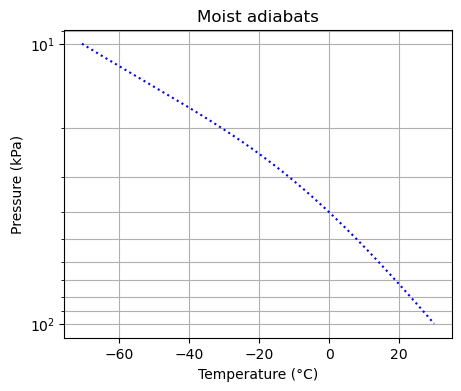

In [67]:
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot()
ax.grid(visible=True, which='major')
ax.grid(axis='both', visible=True, which='minor')
ax.yaxis.set_inverted(True)
ax.set_title("Moist adiabats")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Pressure (kPa)")
ax.semilogy(m_adiabat, p, color='blue', linestyle=':')

In [68]:
def p_moist_adiabats():
    '''
    This function computes a set of moist adiabats
    '''
    adiabats = [] 
    t_0 = np.array([-60, -50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50, 60])
    for i in range(len(t_0)):
        T = moist_adiabat(t_0[i])
        adiabats.append(T)
    return adiabats

In [69]:
m_adiabats = p_moist_adiabats()

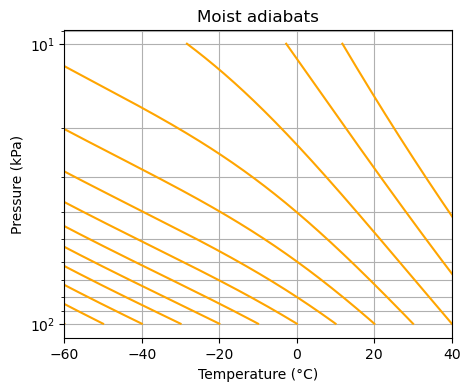

In [70]:
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot()
ax.grid(visible=True, which='major')
ax.grid(axis='both', visible=True, which='minor')
ax.set_xlim(-60, 40)
ax.yaxis.set_inverted(True)
ax.set_title("Moist adiabats")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Pressure (kPa)")
for i in range(len(m_adiabats)):
    ax.semilogy(m_adiabats[i], p, color='orange')

## Constants
Atmospheric variables and conversion functions use several physical and chemical constants. While easy to write these constants are already available in weather packages such as [MetPy](https://unidata.github.io/MetPy/latest/api/generated/metpy.constants.html) and [earthkit-meteo](https://earthkit-meteo.readthedocs.io/en/latest/autoapi/earthkit/meteo/constants/index.html#earthkit.meteo.constants). For instance, the latent heat of vaporization of liquid water $L_v$

In [2]:
from earthkit.meteo import constants as const
const.Lv

2500800.0

and the specific heat of water vapour at constant pressure $C_{pv}$

In [3]:
const.c_pv

1846.1

They may differ slightly depending on the source used, e.g. WMO or other organizations.

In [7]:
from metpy import constants as mpconst
mpconst.Lv

<Quantity(2500840.0, 'joule / kilogram')>

In [8]:
mpconst.Cp_v

<Quantity(1860.07801, 'joule / kilogram / kelvin')>

## Moisture variables
The water content in the atmosphere can be represented using several variables: mixing ratio, specific humidity, absolute humidity, relative humidity, dew point.

### Mixing ratio
While the mixing ratios of other gases in the atmosphere are well mixed and is constant with height, the water vapor mixing ratio $r$ can change in time and space. It is defined as the ratio of mass of water vapor to the mass of the dry air
$$r = \frac{m_v}{m_d}$$
where $m_v$ is the mass, in Kg of the water vapor and $m_d$ is the mass of dry air.

### $\epsilon$ ratio 
It is defined as the ratio between the dry air gas constant $R_d$ and the water vapor gas constant $R_v$
$$\epsilon = \frac{R_d}{R_v} = \frac{M_v}{M_d} = \frac{18.0}{28.96} = 0.6215$$
where $M_v$ is the water vapor molar mass, that is the mass of one mole of water molecules, and $M_d$ is the molar mass of dry air that is defined as a mixture of nitrogen, oxygen, argon.

### Conversion between mixing ratio and vapor pressure
We use the gas law for water vapor $e$ and for the air $p$. The total pressure of moist air is
$$P = p + e$$
For water vapor the gas law is
$$eV = \frac{m_w}{M_v}RT$$
and for dry air is
$$pV = \frac{m_d}{M_d}RT$$
From the last two equations we have
$$m_v = \frac{M_v eV}{RT}$$
and
$$m_d = \frac{M_d pV}{RT}$$
so that for the water vapor mixing ratio we have
$$r = \frac{e}{p} \frac{M_v}{M_d} = \frac{\epsilon e}{p} = \frac{\epsilon e}{P - e}$$
From the last expression we can calculate the vapor pressure from the water vapor mixing ratio and the pressure of the moist air
$$e = \frac{rP}{\epsilon + r}$$
Since $P \gg e$, we can approximate 
$$r  \approx \frac{\epsilon e}{P}$$
and
$$e \approx \frac{rP}{\epsilon}$$

### Specific humidity
The specifi humidity is similar to the water vapor mixing ration. It is defined as the ratio of the mass of water vapor $m_v$ to the mass of the moist air $m_a$
$$q = \frac{m_v}{m_a} = \frac{m_v}{m_d + m_v}$$

### Relative humidity
It is defined as the ratio between the water vapor pressure $e$ and its value at saturation $e_s$, usually in percentage
$$RH = \frac{e}{e_s} \times 100$$

### Virtual temperature
It is defined as the temperature of dry air when water vapor is taken into account. From the [Dalton's law of partial pressures](https://en.wikipedia.org/wiki/Dalton%27s_law) the pressure of moist air $P$ is the sum of the pressure of water vapor $e$ and that of dry air $p$
$$PV = (p + e)V = \frac{m_d}{M_d}RT + \frac{m_v}{M_v}RT = RT(\frac{m_d}{M_d} + \frac{m_v}{M_v})$$
and 
$$p + e = \frac{RT}{V} (\frac{m_d}{M_d} + \frac{m_v}{M_v})$$

The density $\rho$ of moist air is the sum of the densities of water vapor and dry air

$$\rho = \rho_v + \rho_d = \frac{m_v}{V} + \frac{m_d}{V} = \frac{m_v + m_d}{V}$$

so that 

$$\frac{1}{V} = \frac{\rho}{m_v + m_d}$$

and 

$$p + e = \rho RT \frac{\frac{m_d}{M_d} + \frac{m_v}{M_v}}{m_v + m_d}$$

From the definition of the water vapor mixing ratio $r$ we have

$$m_v = rm_d$$

From the definition of the ratio $\epsilon$

$$M_v = \epsilon M_d$$

Substituting these values into the expression of the Dalton's law we have

$$P = p + e = \rho \frac{R}{M_d}T \frac{1 + \frac{r}{\epsilon}}{1 + r}$$
Setting the gas constant for dry air
$$R_d = \frac{R}{M_d}$$
and the temperature of moist air, also known as the *virtual temperature*
$$T_v = T \frac{1 + \frac{r}{\epsilon}}{1 + r}$$
we can write the equation of state for moist air as
$$P = \rho R_d T_v$$

### Dew point temperature $T_d$
By defiinition, it is the temperature $T_d$ to which moist air must be cooled, with pressure and water vapor mixing ratio held constant, for it to reach saturation with respect to water. It can be calculated analytically from the Clausius-Clapeyron equation

$$e = e_0 e^{\frac{\lambda M}{R}(\frac{1}{T_0} - \frac{1}{T_d})}$$

From the equation after some manipulation we get

$$ln\frac{e}{e_0} = \frac{\lambda M_v}{R}(\frac{1}{T_0} - \frac{1}{T_d})$$

and after setting

$$R_v = \frac{R}{M_v}$$

we have

$$T_d = [\frac{1}{T_0} - \frac{R_v}{\lambda} ln \frac{e}{e_0}]^{-1}$$

The dew point temperature can also be obtained from a tephigram. Starting from a point (p,T) in the thermo diagram one has to
1. Move along the adiabatic passing through (p,T) up to the isohume with the given mixing ratio 
2. Follow the isohume down to the given isobar at costant pressure p
3. Follow the isotherm down to the temperature axis

From the dew point we can calculate the mixing ratio. Using the approximation

$$r = \frac{\epsilon e}{p} = \frac{\epsilon e_0}{p} e^{\frac{L_v}{R_v}(\frac{1}{T} - \frac{1}{T_d})} $$

In [9]:
from earthkit.meteo import constants as c
def mixing_ratio(dew_point_celsius, p):
    '''
    This function calculates the water vapor mixing ratio from
    the dew point temperature and the air pressure. It returns
    the mixing ratio as kg_water/kg_air
    '''
    e_0 = 0.6113 # water vapor pressure at T_0
    T_d = dew_point_celsius + c.T0
    return c.epsilon * e_0 * np.exp(c.Lv / c.Rv * (1 / c.T0 - 1 / T_d)) / p

In [10]:
T_d = 10 # °C
p = 101 # kPa
mixing_ratio(T_d, p)

0.007585110899264827

### Wet-bulb temperature $T_w$
By definition, it is the temperature to which moist air can be cooled at constant pressure by water evaporation until saturation is reached. From the 1st principle of Thermodynamics we have
$$c_pdT = - \lambda dw$$
where $dw$ is the element of mass of water lost by evaporation given as change in mixing ratio. Integrating both members of the equation we get
$$c_p(T-T_w) = -\lambda (r - r_s)$$
where $w_s$ is the saturated water. Manipulating the equation we get the wet-bulb temperature
$$T_w = T + \frac{\lambda}{c_p}(r -r_s)$$

### Lifting condensation level
The [lifting condensation level](https://en.wikipedia.org/wiki/Lifting_condensation_level) is the height at which a parcel of moist air becomes saturated. Beyond that height water vapor starts to condense with the formation of cloud drops. The LCL can be determined from a thermodiagram or analytically. The analytical formula to compute the LCL can be obtained from the difference between the dry air lapse rate $\Gamma_d$ and the dew point lapse rate $\Gamma_{dew}$. An analytical estimation of the dew point lapse rate is provided in the appendix. For the ambient dry air we have 

$$T_{lcl} = T + \Gamma_d z_{lcl}$$

and for the moist air going up to the LCL we have

$$T_{lcl} = T_d + \Gamma_{dew} z_{lcl}$$

From the two equations we can calculate $z_{lcl}$ 

$$z_{lcl} = \frac{T - T_d}{\Gamma_d - \Gamma_{dew}}$$

In thermostatic equilibrium for the dry air lapse rate we have

$$\Gamma_d = -\frac{g}{C_{pd}}$$

where g is the gravity accelleration and $C_{pd}$ is the specific heat at constant pressure for dry air. For the dew point lapse rate we have

$$\Gamma_{dew} = -\frac{g}{\epsilon L_v} T_d$$

where $\epsilon$ is the ratio between the dry air gas constant $R_d$ and the water vapor gas constant $R_v$.

In [9]:
dry_lapse_rate = -ekconst.g / ekconst.c_pd
dry_lapse_rate

-0.009759900078623394

In [10]:
t_d = 290
dew_lapse_rate = -ekconst.g * t_d / (ekconst.epsilon * ekconst.Lv)  
dew_lapse_rate

-0.0018283637178660558

In [11]:
a = 1 / (dew_lapse_rate - dry_lapse_rate)
a

126.07897821003188

We calculate the lifting condensation point $z_{LCL}$

In [12]:
T = 25 + 273.15
T_d = 15 + 273.15
lcl = a * (T - T_d)
lcl

1260.7897821003187

We calculate the pressure at the LCL using the equation in 4.16b in [Stull].

In [13]:
p = 1000
p_lcl = p * (1 - a * dry_lapse_rate * ((T_d - T)/T)) ** 3.5
p_lcl

862.8479716592983

We can also calculate the pressure at LCL from the hydrostatic equation
$$p_{lcl}=p_0 exp{-\frac{g z_{lcl}}{R_d T}}$$

In [14]:
import math
p_lcl_exp = p * math.exp(-ekconst.g * lcl /(ekconst.Rd * T))
p_lcl_exp

865.4870251372244

Finally we calculate the temperature at LCL using the equation for the potential temperature (dry adiabat)
$$T_{lcl} = T (\frac{p_{lcl}}{p})^{\frac{R_d}{C_{pd}}}$$

In [15]:
t_lcl = T * (p_lcl_exp / p) ** (ekconst.Rd / ekconst.c_pd) 
t_lcl - 273.15

12.945288506539839

We can use MetPy to calculate the LCL, given pressure, temperature and dew point

In [16]:
from metpy.calc import lcl
from metpy.units import units

In [17]:
pressure = 1000 * units.hPa
temperature = 25 * units.degC
dewpoint = 15 * units.degC

In [18]:
lcl_pressure, lcl_temperature = lcl(pressure, temperature, dewpoint)

In [19]:
print(f"LCL Pressure: {lcl_pressure:.2f}")
print(f"LCL Temperature: {lcl_temperature:.2f}")

LCL Pressure: 862.87 hectopascal
LCL Temperature: 12.73 degree_Celsius


In [20]:
from earthkit.meteo.thermo import array
pressure = 1000
temperature = 25 + 273.15
dewpoint = 15 + 273.15
t_lcl, p_lcl = array.lcl(temperature, dewpoint, pressure, method='davies')
print(f"LCL Pressure (Pa): {p_lcl:.2f}")
print(f"LCL Temperature (K): {t_lcl - 273.15 :.2f}")

LCL Pressure (Pa): 863.46
LCL Temperature (K): 12.75


# Appendix - The dew point lapse rate
The idea in order to calculate the LCL level is to find the height where the temperature of the dry air and that of a moist parcel are the same. The assumption is that the parcel will follow a dry adiabat till the height where the water vapor starts to condense. We use the relation, approximated, between the water vapor mixing ratio and the water vapor pressure
$$e = \frac{rp}{\epsilon}$$
Differentiating both members with respect to the dew point temperature we have
$$\frac{de}{dT_d} = \frac{r}{\epsilon} \frac{dp}{dT_d}$$
From the Clausius-Clapeyron equation we have
$$\frac{de}{e}= \frac{L_v}{R_v T_d^2} dT_d$$
and 
$$\frac{de}{dT_d}= \frac{L_v e}{R_v T_d^2}$$
From the two derivatives of the water vapor pressure we have
$$\frac{r}{\epsilon} \frac{dp}{dT_d} = \frac{L_v e}{R_v T_d^2}$$
and
$$\frac{dp}{dT_d}=\frac{L_v p}{R_v T_d^2}$$
From the hydrostatic assumption
$$dp = -\rho g dz$$
and the gas law
$$\rho = \frac{p}{R_d T}$$
we have
$$dp = -\frac{gp}{R_d T} dz$$
so that, assuming $T \approx T_d$
$$\frac{dz}{dT_d} = -\frac{\epsilon L_v}{g T_d}$$
and
$$\frac{dT_d}{dz} = -\frac{g T_d}{\epsilon L_v}$$
From this last equation we can define the dew point lapse rate $\Gamma_{dew}$, that is lapse rate with which unsatureted moist air becomes satureted
$$\Gamma_{dew} = \frac{dT_d}{dz} = -\frac{g T_d}{\epsilon L_v}$$

## References and datasets
* [Randall - The Moist Adiabatic Lapse Rate](https://hogback.atmos.colostate.edu/group/dave/pdf/Moist_adiabatic_lapse_rate.pdf)